![Photo by DAVID SWANSON/AFP via Getty Images](/images/palisade_fire2.jpg)

## Background
The fire hazard conditions in Los Angeles County on January 7, 2025 were a coalescence of drought brought on by months without rainfall and Santa Ana winds that ripped through the dry brush in the Santa Monica mountains and Eaton Canyon. Fires in the Pacific Palisades and Eaton areas began to burn and spread quickly that morning due to the wind conditions, and several other fires burning strained fire response resources. The Los Angeles County Eaton and Palisades Fires After-Action Reviews highlighted that the county's issuance of evacuation warnings was complicated by fire conditions and the speed capability of public warnings systems. This emphasized issues with the timeliness of evacuation orders issued by the county. The fires resulted in 31 deaths total reported by the county, and affected more than 43,000 residents.


## Purpose
The scale of the Palisades and Eaton fires necessitated geospatial analysis to determine their effects. The goal of this post is to explore data pertaining to the Los Angeles County areas affected by the Palisades and Eaton Fires, and produce visualizations that aid in interpretting human and environmnental impact. These analyses were done in Python as work for EDS220 in the Bren MEDS program. 

## Data sources

### Landsat 8 Satellite Data
Landsat remote sensing data is a useful tool for creating true and false color images, particularly as it relates to vegetation, which can be useful for visualizing burn area. We used a Landsat Collection 2 Level-2 atmosperically corrected surface reflectance dataset, collected by the Landsat 8 satellite. The data contain red, green, blue, NIR, and SWIR bands. Data was retrieved from the Microsoft Planetary Computer data catalogue and clipped to the area around Palisades/Eaton fire perimeters.

Planetary Computer. Microsoft Planetary Computer. https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2


### California State Fire Perimeters Data
California has publicly accessible historical fire data available over a nearly 75 year period. The California Historical Fire Perimeters dataset was retrieved from the California State Geoportal Historical Wildland Fire Perimeters database. The data include many qualitative variables about fire impact, and importantly includes geographic data with fire id and specific date information.

California State Geoportal. California Historical Fire Perimeters [Dataset]. https://gis.data.ca.gov/datasets/CALFIRE-Forestry::california-historical-fire-perimeters/explore?layer=2&location=37.338129%2C-119.269051%2C6.09&showTable=true

### Environmental Justice Index (EJI) 2024
EJI provides nationwide data in the U.S. to represent environmental and health inequity issues. EJI's geodatabase was used in socioeconomic analysis as it relates to the impacts of the 2025 wilfires. 

Centers for Disease Control and Prevention, Agency for Toxic Substances and Disease Registry, Geospatial Research, Analysis, and Services Program (GRASP). 2024 EJI Technical Documentation. 


## Setup code and preliminary cleaning

In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rio
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar

# Read in datasets
landsat = xr.open_dataset('data/landsat8-2025-02-23-palisades-eaton.nc', engine='netcdf4')

fp = os.path.join('data', 'California_Historic_Fire_Perimeters_-247493000743518952', 'California_Fire_Perimeters_(1950+).shp')
fires = gpd.read_file(fp)

fp= os.path.join('data', 'EJI_2024_United_States', 'EJI_2024_United_States.gdb')
eji = gpd.read_file(fp)

fires.columns = fires.columns.str.lower()
fires_crs = fires.crs
palisade = fires[(fires['fire_name'] == 'PALISADES') & (fires['year_'] == 2025)]
eaton = fires[(fires['fire_name'] == 'EATON') & (fires['year_'] == 2025)]

The python libraries needed to process the data described above were `numpy`, `pandas`, `geopandas`, `xarray`, `rioxarray`, `matplotlib`, `contextily`, and `ScaleBar` from `matplotlib_scalebar.scalebar` to produce the full final visualization. 

Fire data were filtered to contain only the Palisades and Eaton fires from 2025, and the column names were standardized. We needed to combine datasets in order to extract information from multiple at once, so in preliminary analysis it was important to know what the coordinate reference system (CRS) was of each dataset. The fire data had the  CRS EPSG:3857.

The Landsat data are stored in a NetCDF4 file. `.nc` files contain nested metadata and attributes that make processing less reliant on outside research and interpretation. This is an extremely useful format, but the processing steps look a bit different than for a `pd.Series` or `gpd.GeoDataFrame`. 

## Landsat data processing

In [ ]:
# Find CRS of spatial reference in landsat data itself
crs = landsat.spatial_ref.crs_wkt

# Set the crs of landsat equal to that of the spatial reference
landsat.rio.write_crs(crs, inplace= True)

Because of the way NetCDFs are structured, there is not a CRS explicitly contained by the `.nc` itself. If you run `landsat.rio.crs` to check the CRS of teh dataset, it will return 'None'. This must be pulled out of the spatial reference of the data itself. The crs is then assigned to the landsat data object.

In [ ]:
# Create numpy array with true color bands 
true_col = landsat[["red", "green", "blue"]].to_array()

# Fill missing values in landsat data
landsat = landsat.fillna(0)

# Rerender plot without warnings
landsat[["red", "green", "blue"]].to_array().plot.imshow(robust = True)

In [ ]:
# Switch band order around to create false color image
plt.show(landsat[["swir22", "nir08", "red"]].to_array().plot.imshow(robust = True))

In [ ]:
# Filter for Palisades fire data from 2025
palisade_perimeter = fires[(fires['fire_name'] == 'PALISADES') & (fires['year_'] == 2025)]

# Filter for Eaton fire 2025
eaton_perimeter = fires[(fires['fire_name'] == 'EATON') & (fires['year_'] == 2025)]

# Change CRS of fires data to match that of landsat data
palisade_perimeter = palisade_perimeter.to_crs(crs = 'EPSG:32611')
eaton_perimeter = eaton_perimeter.to_crs(crs = 'EPSG:32611')

# Initialize plot
fig, ax = plt.subplots(figsize = (10, 10))

# Underlay landsat false color image plot
landsat[["swir22", "nir08", "red"]].to_array().plot.imshow(ax=ax, 
                                                           robust = True)

# Add Palisade fire area onto plot
palisade_perimeter.plot(ax=ax, color = 'red', alpha = 0.5)

# Add Eaton fire area onto plot
eaton_perimeter.plot(ax=ax, color = "red", alpha = 0.5)

# Add informative title
plt.title("False Color Map of the Locations of January 2025 Los Angeles County Fires")

# Add a scalebar with matplotlib ScaleBar function
scalebar = ScaleBar(dx = 1, # Specify resolution of cell being measured
                     units = 'm', # Cells are 1m res
                     location = "lower left") # Add to lower left of plot
ax.add_artist(scalebar)

# Add compass arrow by initializing area on plot and size
x, y, arrow_length = 0.95, 0.2, 0.15

# Add annotation with text and arrow/text
ax.annotate('N', xy=(x, y), xytext=(x, y-arrow_length),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            ha='center', va='center', fontsize=15,
            xycoords=ax.transAxes)

# Add Palisade fire annotation
fig.text(x = 0.25, 
         y = 0.52, 
         s = "Palisades fire", 
         backgroundcolor = 'white')

# Add Eaton fire annotation
fig.text(x = 0.7, 
         y = 0.63, 
         s = "Eaton fire", 
         backgroundcolor = 'white')

# Add label to downtown Los Angeles for visual context
fig.text(x = 0.56, 
         y = 0.4, 
         s = "Los Angeles", 
         color = 'white', 
         fontsize = 'large')

# Remove axes ticks
ax.set_xticks([])  
ax.set_yticks([])  

# Remove axes labels
ax.set_xlabel("")  
ax.set_ylabel("")  

plt.show()

In [ ]:

eji = eji.to_crs(crs = fires.crs)

In [18]:
# Spatial join
palisade_soc = gpd.sjoin(left_df = eji, 
                        right_df = palisade,
how = 'inner')

# Create geodf for the Eaton fire
# Spatial join
eaton_soc = gpd.sjoin(eji, eaton,
how = 'inner')

# Clip the census tracts overlapping palisades to the boundary of the fire
palisade_clip = gpd.clip(eji, palisade)

eaton_clip = gpd.clip(eji, eaton)

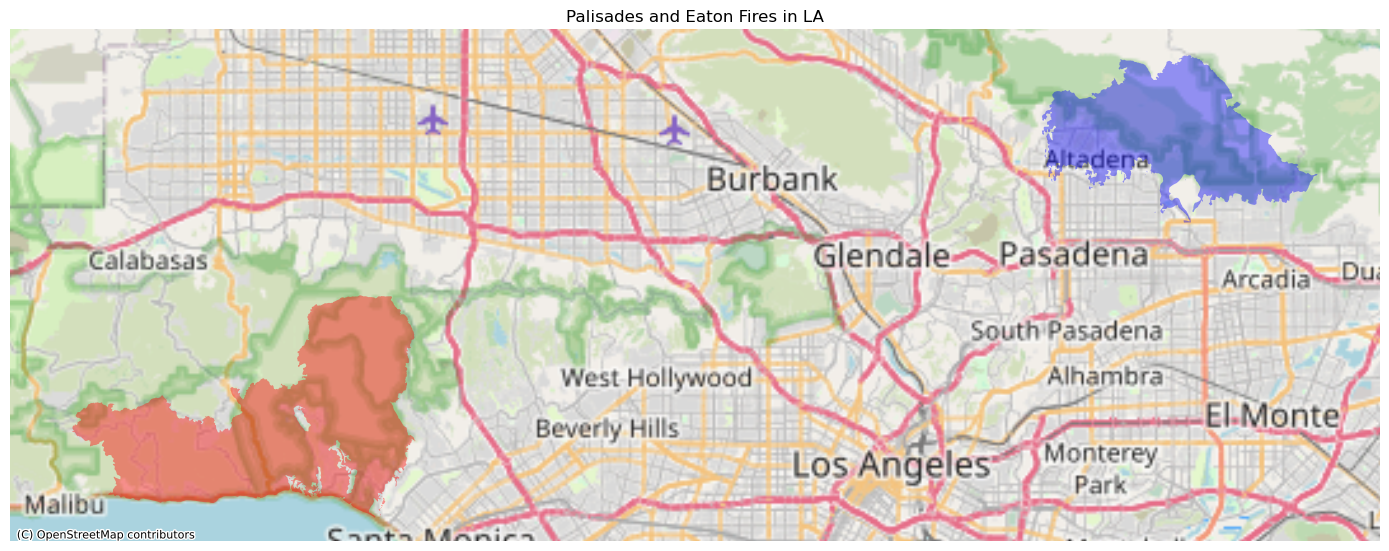

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

palisade.plot(ax=ax, color = "red", alpha = 0.4)

eaton.plot(ax=ax, color = "blue", alpha = 0.4)
# Add basemap using contextily
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs = palisade.crs)

ax.set_title("Palisades and Eaton Fires in LA")

ax.axis('off')

plt.tight_layout()
plt.show()

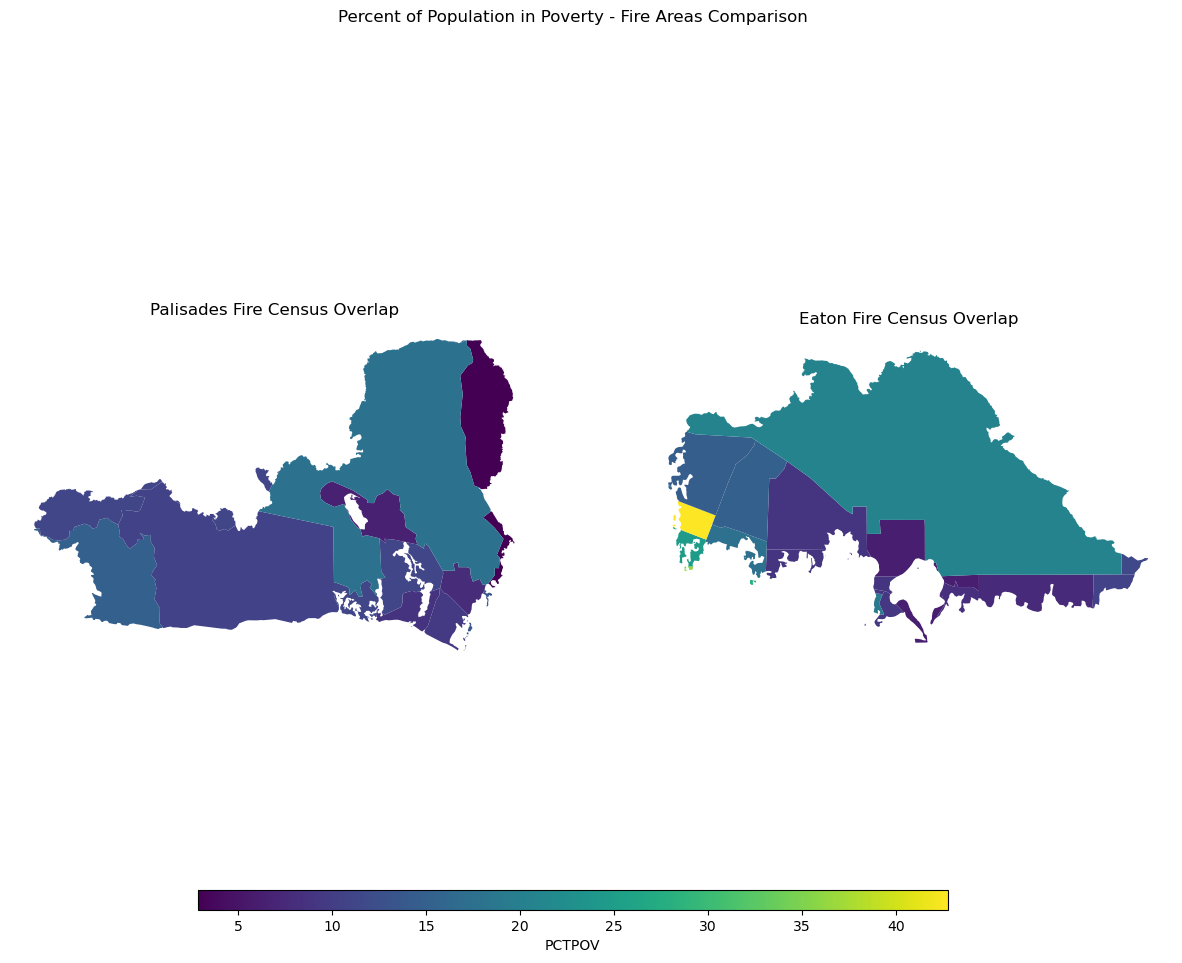

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))

# UPDATE WITH YOU EJI VARIABLE FROM STEP 1
eji_variable = 'E_POV200'

# Find common min/max for legend range
vmin = min(palisade_clip[eji_variable].min(), eaton_clip[eji_variable].min())
vmax = max(palisade_clip[eji_variable].max(), eaton_clip[eji_variable].max())

# Plot census tracts within Palisades perimeter
palisade_clip.plot(
    column= eji_variable,
    vmin=vmin, vmax=vmax,
    legend=False,
    ax=ax1,
)
ax1.set_title('Palisades Fire Census Overlap')
ax1.axis('off')

# Plot census tracts within Eaton perimeter
eaton_clip.plot(
    column=eji_variable,
    vmin=vmin, vmax=vmax,
    legend=False,
    ax=ax2,
)
ax2.set_title('Eaton Fire Census Overlap')
ax2.axis('off')

# Add overall title
fig.suptitle('Percent of Population in Poverty - Fire Areas Comparison')

# Add shared colorbar at the bottom
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('PCTPOV')

plt.show()